# Prac 06.1

For this homework we are not going to provide you with any code, you'll have to build the face detector on your own.

### Step 0

Run the necessary imports.

In [55]:
import os

import cv2
import dlib

import numpy as np

from matplotlib import pyplot as plt

In [56]:
def read_image(image_path: str, plot: bool = False) -> np.ndarray:
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    if plot:
        plt.imshow(img)
        plt.axis('off')
        plt.show()
    return img

def show_compare(images: list, image_names: list = [], special_cmap: dict = {}):
    count = len(images)
    count_names = len(image_names)
    fig, axes = plt.subplots(1, count)
    if count == 1:
        axes = [axes]
    for cnt in range(count):
        if cnt in special_cmap or -(count - cnt) in special_cmap:
            axes[cnt].imshow(images[cnt], cmap=special_cmap.get(cnt, special_cmap.get(-(count - cnt))))
        else:
            axes[cnt].imshow(images[cnt])
        axes[cnt].axis('off')
        if cnt < count_names:
            axes[cnt].set_title(image_names[cnt])
    plt.show()

### Step 1

Load an image (any image that contains faces).

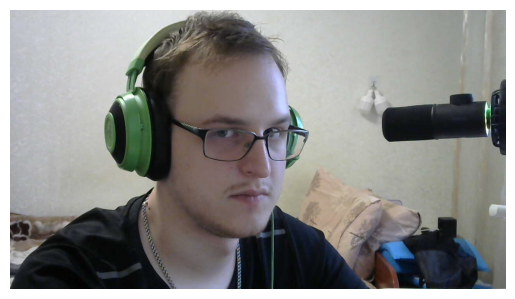

In [57]:
image = read_image("../Data/face.jpg", True)

### Step 2

Load the dlib face predictor.

In [58]:
face_detector = dlib.get_frontal_face_detector()

### Step 3

Run the predictor on your image.

### Step 4

Draw bounding boxes around the detected faces and plot the image. Use different colour for each face.

[ ] Faces detected to draw boxes: rectangles[[(404, 197) (775, 569)]]


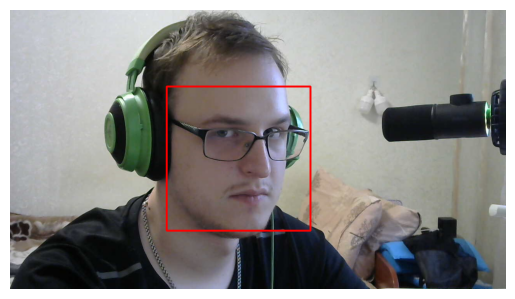

In [59]:
def create_image_with_boxes(image: np.ndarray, thickness: int = 4) -> np.ndarray:
    image_with_boxes = image.copy()
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (0, 255, 255), (255, 0, 255)]

    detected_faces = face_detector(image)

    if not detected_faces: print("[!] No faces detected to draw boxes.")
    else:
        print(f"[ ] Faces detected to draw boxes: {detected_faces}")
        for i, face_rect in enumerate(detected_faces):
            left, top, right, bottom = face_rect.left(), face_rect.top(), face_rect.right(), face_rect.bottom()

            color = colors[i % len(colors)]

            cv2.rectangle(image_with_boxes, (left, top), (right, bottom), color, thickness=thickness)

    return image_with_boxes


image_with_boxes = create_image_with_boxes(image)
plt.imshow(image_with_boxes)
plt.axis('off')
plt.show()

### Step 5 (optional)

Repeat the process with a different and more challenging image (more faces, smaller faces, people with glasses, hats, helmets, etc.). How does the detector perform? Is it robust?

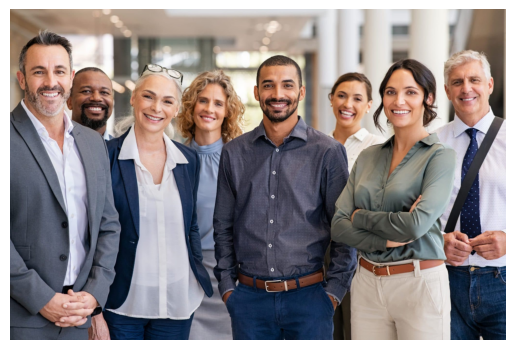

[ ] Faces detected to draw boxes: rectangles[[(1528, 293) (1707, 473)], [(1322, 327) (1472, 476)], [(66, 209) (281, 424)], [(512, 313) (691, 492)], [(742, 344) (891, 493)], [(997, 257) (1212, 472)], [(1786, 254) (1966, 433)], [(273, 293) (453, 473)], [(908, 369) (1033, 494)]]


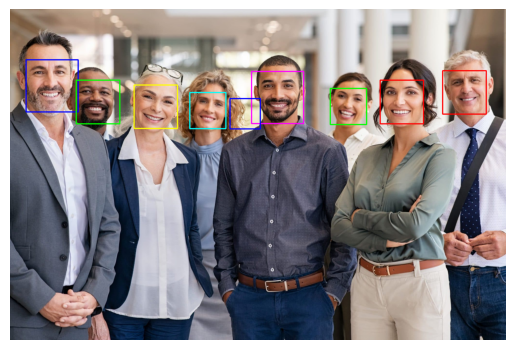

In [60]:
image_new = read_image("../Data/faces.jpg", plot=True)
image_with_boxes = create_image_with_boxes(image_new)
plt.imshow(image_with_boxes)
plt.axis('off')
plt.show()

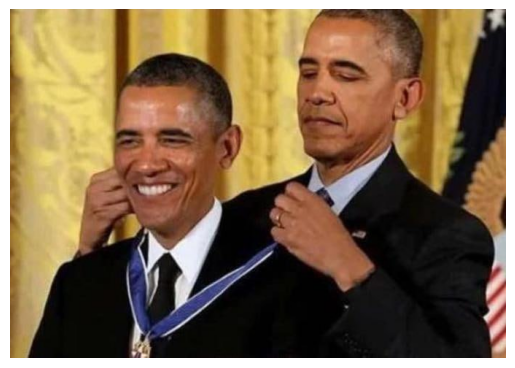

[ ] Faces detected to draw boxes: rectangles[[(360, 29) (510, 178)], [(128, 128) (277, 277)]]


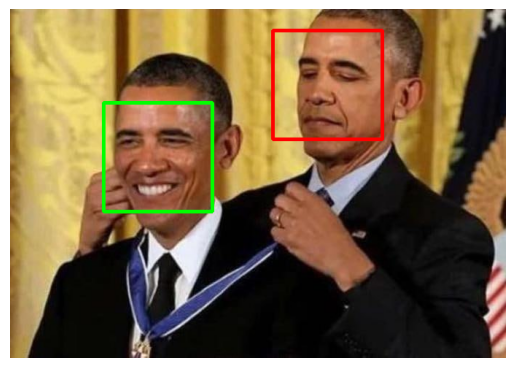

In [61]:
image_new = read_image("../Data/faces1.jpg", plot=True)
image_with_boxes = create_image_with_boxes(image_new)
plt.imshow(image_with_boxes)
plt.axis('off')
plt.show()